# ACDC 数据集可视化

本笔记本用于可视化 ACDC (Automated Cardiac Diagnosis Challenge) 数据集中的样本。

In [1]:
# 安装必要的库
!pip install nibabel matplotlib numpy

Looking in indexes: https://mirrors.aliyun.com/pypi/simple
  Using cached https://mirrors.aliyun.com/pypi/packages/b8/f5/7f6aa3bbff013c0bf993129cbb2b1505790091f812accbe85cf001514737/nibabel-5.3.3-py3-none-any.whl (3.3 MB)


In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

# 设置路径
data_dir = 'dataset/ACDC_Data/training'
patient_id = 'patient001'
frame_id = '01'

patient_path = os.path.join(data_dir, patient_id)
img_path = os.path.join(patient_path, f'{patient_id}_frame{frame_id}.nii')
gt_path = os.path.join(patient_path, f'{patient_id}_frame{frame_id}_gt.nii')

print(f"Loading image from: {img_path}")
print(f"Loading ground truth from: {gt_path}")

# 加载数据
try:
    img_nii = nib.load(img_path)
    gt_nii = nib.load(gt_path)

    img_data = img_nii.get_fdata()
    gt_data = gt_nii.get_fdata()

    print(f"Image shape: {img_data.shape}")
    print(f"GT shape: {gt_data.shape}")
    print(f"Unique labels in GT: {np.unique(gt_data)}")
except Exception as e:
    print(f"Error loading data: {e}")

Loading image from: dataset/ACDC_Data/training/patient001/patient001_frame01.nii
Loading ground truth from: dataset/ACDC_Data/training/patient001/patient001_frame01_gt.nii
Image shape: (216, 256, 10)
GT shape: (216, 256, 10)
Unique labels in GT: [0. 1. 2. 3.]


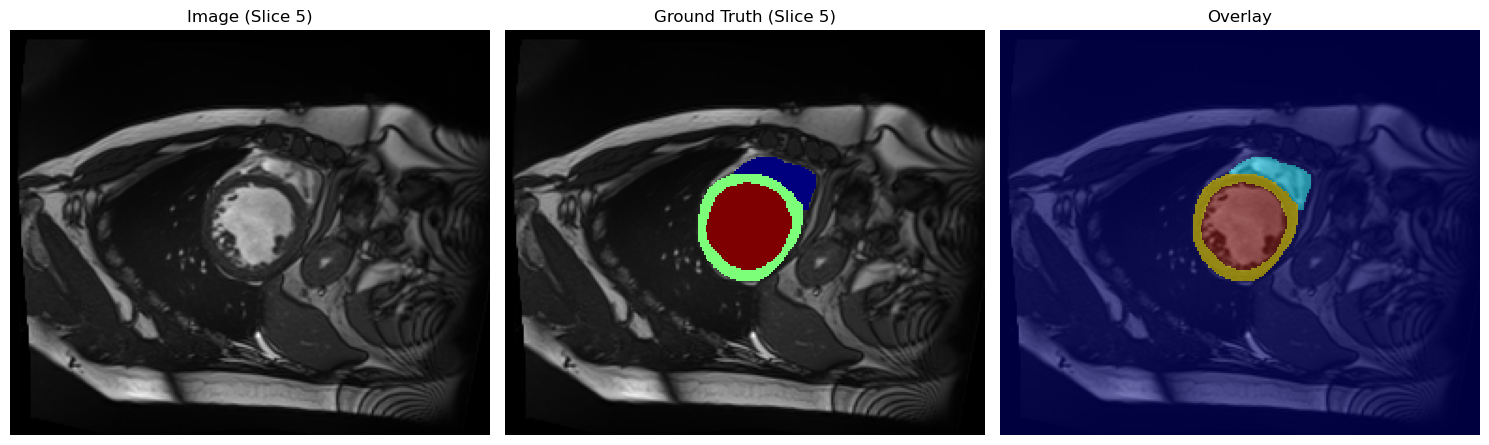

In [3]:
def visualize_sample(img, gt, slice_idx=None):
    if slice_idx is None:
        slice_idx = img.shape[2] // 2
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title(f'Image (Slice {slice_idx})')
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title(f'Ground Truth (Slice {slice_idx})')
    # 使用 masked array 隐藏背景 (0)
    masked_gt = np.ma.masked_where(gt[:, :, slice_idx] == 0, gt[:, :, slice_idx])
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.imshow(masked_gt, cmap='jet', interpolation='none')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title('Overlay')
    plt.imshow(img[:, :, slice_idx], cmap='gray')
    plt.imshow(gt[:, :, slice_idx], cmap='jet', alpha=0.5, interpolation='none')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 可视化中间切片
if 'img_data' in locals():
    visualize_sample(img_data, gt_data)

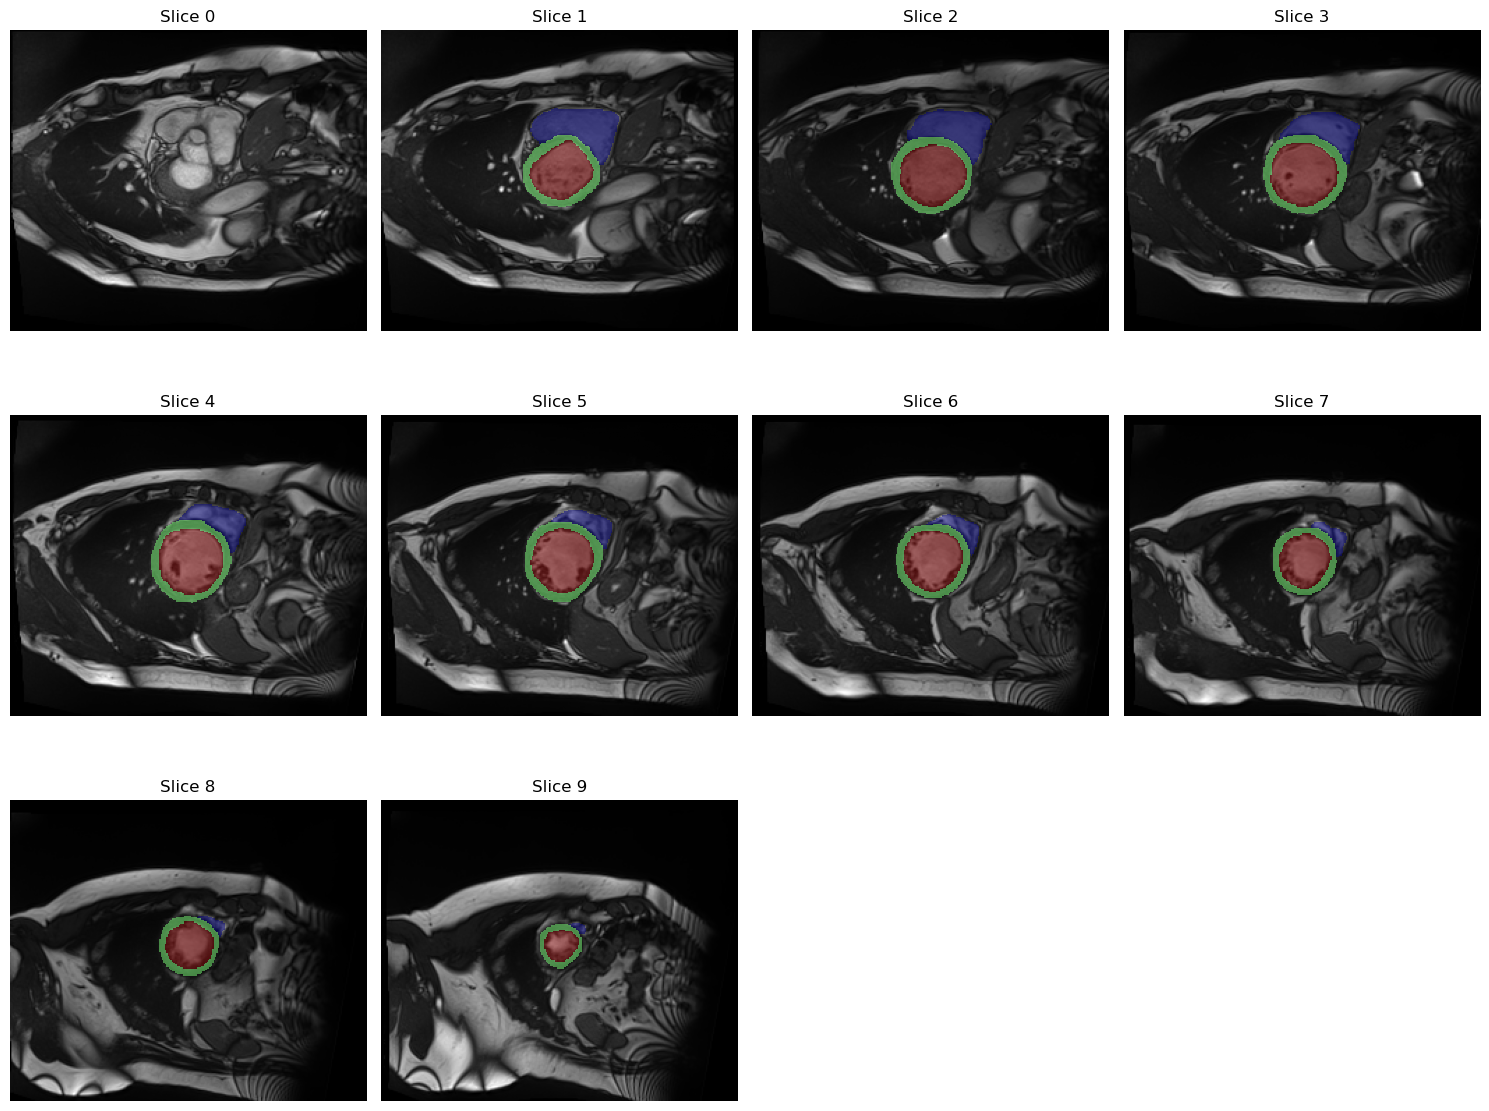

In [4]:
# 可视化所有切片
if 'img_data' in locals():
    num_slices = img_data.shape[2]
    cols = 4
    rows = (num_slices + cols - 1) // cols

    plt.figure(figsize=(15, 4 * rows))
    for i in range(num_slices):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_data[:, :, i], cmap='gray')
        masked_gt = np.ma.masked_where(gt_data[:, :, i] == 0, gt_data[:, :, i])
        plt.imshow(masked_gt, cmap='jet', alpha=0.5, interpolation='none')
        plt.title(f'Slice {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()